# General

For more informations, si the documentation *Documentary Strategy*.

# Import & Configs

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from Bio import Medline
from io import StringIO

# Data Upload

In [2]:
def  get_documents_df():
    documents = []
    
    with open("../data/raw/pubmed_abstracts.jsonl", "r") as f:
        for line in f:
            documents.append(json.loads(line))

    df = pd.DataFrame(documents)
    return df

In [3]:
df = get_documents_df()
df.head()

,query,pmid,raw_text
0,glioblastoma,42277245,\nPMID- 42277245\nOWN - NLM\nSTAT- Publisher\n...
1,glioblastoma,42276782,\nPMID- 42276782\nOWN - NLM\nSTAT- Publisher\n...
2,glioblastoma,42276409,\nPMID- 42276409\nOWN - NLM\nSTAT- Publisher\n...
3,glioblastoma,42276258,\nPMID- 42276258\nOWN - NLM\nSTAT- Publisher\n...
4,glioblastoma,42276218,\nPMID- 42276218\nOWN - NLM\nSTAT- Publisher\n...


In [4]:
len(df)

5801

All documents are loaded.

In [5]:
print(df.iloc[0]["raw_text"][:3000])


PMID- 42277245
OWN - NLM
STAT- Publisher
LR  - 20260611
IS  - 2045-2322 (Electronic)
IS  - 2045-2322 (Linking)
DP  - 2026 Jun 11
TI  - Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical 
      modeling.
LID - 10.1038/s41598-026-57594-z [doi]
AB  - Glioblastoma multiforme (GBM) remains a devastating disease with a poor 
      prognosis. GBM progression generates mechanical forces that compromise blood 
      vessels' functionality, impair perfusion, and create hypoxic regions, which in 
      turn reduce radiosensitivity. While the link between hypoxia and radiosensitivity 
      is known, a quantitative methodology to predict this effect is lacking. Here, we 
      developed a patient-specific mechanistic mathematical model of radiotherapy that 
      integrates Magnetic Resonance Elastography (MRE) imaging. The model can translate 
      MRE-derived stiffness into spatial maps of mechanical stress and simulate 
      subsequent events, such as compressio

-> [Original article page](https://pubmed.ncbi.nlm.nih.gov/42200192/)

-> We have access to some metadata, such as in the bibliography. Because we truncate the printed text, some authors and DOIs are missing.

# Missings

## Missings Abstract

In [6]:
df["has_abstract"] = df["raw_text"].str.contains("AB  -")

df["has_abstract"].value_counts()

has_abstract
True     5702
False      99
Name: count, dtype: int64

In [7]:
df["has_abstract"].value_counts(normalize=True)*100

has_abstract
True     98.293398
False     1.706602
Name: proportion, dtype: float64

## Removing missings abstract

In [8]:
df = df[df["has_abstract"]].copy()

In [9]:
len(df)

5702

## Missings Titles

In [10]:
df["has_title"] = df["raw_text"].str.contains("TI  -")

df["has_title"].value_counts()

has_title
True    5702
Name: count, dtype: int64

## Removing missings titles

In [11]:
df = df[df["has_title"]].copy()

In [12]:
len(df)

5702

## Missings Data

In [13]:
df["has_date"] = df["raw_text"].str.contains("DP  -")

df["has_date"].value_counts()

has_date
True    5702
Name: count, dtype: int64

## Missings PMID

In [14]:
df["has_pmid"] = df["raw_text"].str.contains("PMID-")

df["has_pmid"].value_counts()

has_pmid
True    5702
Name: count, dtype: int64

## Missing Publication Date

In [15]:
df["has_date"] = df["raw_text"].str.contains("DP  -")

df["has_date"].value_counts()

has_date
True    5702
Name: count, dtype: int64

## Missings Publication Type

In [16]:
df["has_publication_type"] = df["raw_text"].str.contains("PT  -")

df["has_publication_type"].value_counts()

has_publication_type
True    5702
Name: count, dtype: int64

## Missings Journal

In [17]:
df["has_publication_type"] = df["raw_text"].str.contains("JT  -")

df["has_publication_type"].value_counts()

has_publication_type
True     5685
False      17
Name: count, dtype: int64

## Missings MeSH

In [18]:
df["has_publication_type"] = df["raw_text"].str.contains("MH  -")

df["has_publication_type"].value_counts()

has_publication_type
True     3427
False    2275
Name: count, dtype: int64

## Missings Keywords

In [19]:
df["has_publication_type"] = df["raw_text"].str.contains("OT  -")

df["has_publication_type"].value_counts()

has_publication_type
True     5007
False     695
Name: count, dtype: int64

## Other missings
Some other metadata may be missing. Since we haven't defined a strategy for metadata, we will not investigate it for now, but we can do so later.

# Abstract sizes

In [20]:
df["text_length"] = df["raw_text"].apply(len)

In [21]:
df["text_length"].describe()

count     5702.000000
mean      5204.850228
std       1895.392931
min       1166.000000
25%       4159.000000
50%       4927.500000
75%       5810.750000
max      31704.000000
Name: text_length, dtype: float64

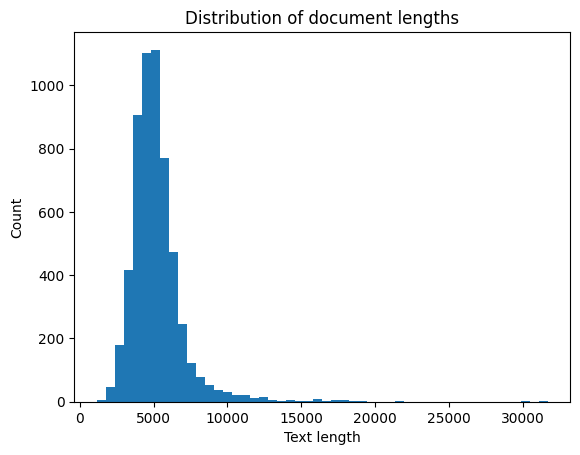

In [22]:
plt.hist(df["text_length"], bins=50)
plt.xlabel("Text length")
plt.ylabel("Count")
plt.title("Distribution of document lengths")
plt.show()

<Axes: ylabel='text_length'>

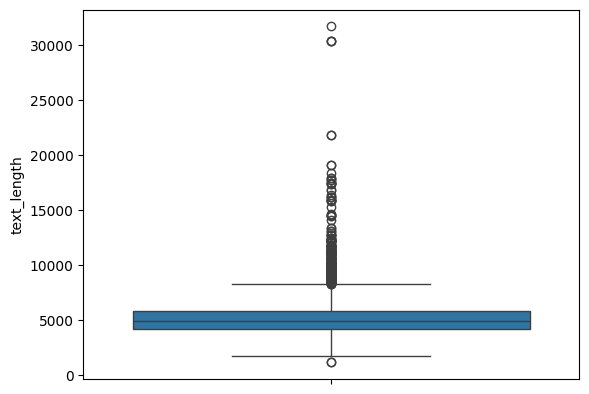

In [23]:
sns.boxplot(data=df["text_length"])

There are some outliers after 9,000 characters. There are no small outliers. The abstracts mainly center around 5,000 characters, forming a Gaussian curve that is slightly more spread out on the right.

# Publications Type

In [24]:
article_types = {}
for index, row in df.iterrows():
    raw_text = row["raw_text"]
    
    record = Medline.read(
        StringIO(raw_text)
    )
    
    publication_types = str(record.get(
        "PT",
        []
    ))

    if publication_types in article_types:
        article_types[publication_types] += 1
    else:
        article_types[publication_types] = 1

article_types

{"['Journal Article']": 1998,
 "['Journal Article', 'Review']": 986,
 "['Journal Article', 'Review', 'Systematic Review']": 79,
 "['English Abstract', 'Journal Article']": 41,
 "['Case Reports', 'Journal Article']": 341,
 "['Journal Article', 'Preprint']": 24,
 "['Journal Article', 'Multicenter Study', 'Observational Study']": 8,
 "['Published Erratum']": 6,
 "['English Abstract', 'Journal Article', 'Review']": 60,
 "['Journal Article', 'Video-Audio Media']": 7,
 "['Case Reports', 'Journal Article', 'Review', 'Systematic Review']": 22,
 "['Clinical Trial, Phase II', 'Journal Article']": 7,
 "['Journal Article', 'Meta-Analysis', 'Review', 'Systematic Review']": 119,
 "['Journal Article', 'Meta-Analysis']": 81,
 "['Journal Article', 'Multicenter Study']": 48,
 "['Clinical Trial Protocol', 'Journal Article']": 4,
 '[\'Case Reports\', \'Journal Article\', "Research Support, Non-U.S. Gov\'t"]': 3,
 "['Clinical Trial, Phase I', 'Clinical Trial, Phase II', 'Journal Article']": 1,
 "['Clinical

In [25]:
article_types = {}
for index, row in df.iterrows():
    raw_text = row["raw_text"]
    
    record = Medline.read(
        StringIO(raw_text)
    )
    
    publication_types = record.get(
        "PT",
        []
    )

    for art_type in publication_types:
        if art_type in article_types:
            article_types[art_type] += 1
        else:
            article_types[art_type] = 1

article_types

{'Journal Article': 5671,
 'Review': 1488,
 'Systematic Review': 1655,
 'English Abstract': 143,
 'Case Reports': 500,
 'Preprint': 24,
 'Multicenter Study': 76,
 'Observational Study': 32,
 'Published Erratum': 6,
 'Video-Audio Media': 11,
 'Clinical Trial, Phase II': 10,
 'Meta-Analysis': 1230,
 'Clinical Trial Protocol': 4,
 "Research Support, Non-U.S. Gov't": 125,
 'Clinical Trial, Phase I': 1,
 'Clinical Trial, Phase III': 3,
 'Randomized Controlled Trial': 6,
 'Research Support, N.I.H., Extramural': 14,
 'Comparative Study': 78,
 'Retraction Notice': 4,
 'Scoping Review': 8,
 'Network Meta-Analysis': 22,
 'Editorial': 4,
 'Retracted Publication': 7,
 'Practice Guideline': 178,
 'Consensus Statement': 6,
 'Guideline': 6,
 'Dataset': 3,
 'Historical Article': 5,
 'Validation Study': 8,
 'Study Guide': 2,
 'Book Chapter': 17,
 'Research Support, N.I.H., Intramural': 2,
 'Clinical Trial': 2,
 'Letter': 7,
 'Clinical Trial, Veterinary': 1,
 'Evaluation Study': 1}

# Structured Parsing

In [27]:
df = get_documents_df()
df.head()

,query,pmid,raw_text
0,glioblastoma,42277245,\nPMID- 42277245\nOWN - NLM\nSTAT- Publisher\n...
1,glioblastoma,42276782,\nPMID- 42276782\nOWN - NLM\nSTAT- Publisher\n...
2,glioblastoma,42276409,\nPMID- 42276409\nOWN - NLM\nSTAT- Publisher\n...
3,glioblastoma,42276258,\nPMID- 42276258\nOWN - NLM\nSTAT- Publisher\n...
4,glioblastoma,42276218,\nPMID- 42276218\nOWN - NLM\nSTAT- Publisher\n...


In [28]:
def extract_pmid(text):

    match = re.search(r"PMID\s*-\s*(\d+)", text)

    if match:
        return match.group(1)

    return None

def extract_title(text):

    match = re.search(
        r"TI\s*-\s*(.*?)(?:\n[A-Z]{2,4}\s*-|\Z)",
        text,
        re.DOTALL
    )

    if match:

        title = match.group(1).strip()

        title = re.sub(r"\s+", " ", title)

        title = title.rstrip(".")

        return title

    return None

def extract_abstract(text):

    match = re.search(
        r"AB\s*-\s*(.*?)(?:\n[A-Z]{2,4}\s*-|\Z)",
        text,
        re.DOTALL
    )

    if match:
        abstract = match.group(1).strip()

        abstract = re.sub(r"\s+", " ", abstract)

        return abstract

    return None

def extract_year(text):

    match = re.search(r"DP\s*-\s*(\d{4})", text)

    if match:
        return match.group(1)

    return None

def extract_journal(text):

    match = re.search(
        r"JT\s*-\s*(.*?)(?:\n[A-Z]{2,4}\s*-|\Z)",
        text,
        re.DOTALL
    )

    if match:

        journal = match.group(1).strip()

        journal = re.sub(r"\s+", " ", journal)

        return journal

    return None
    
def extract_mesh_terms(text):

    matches = re.findall(
        r"MH\s*-\s*(.*)",
        text
    )

    return [m.strip() for m in matches]

def extract_keywords(text):

    matches = re.findall(
        r"OT\s*-\s*(.*)",
        text
    )

    return [m.strip() for m in matches]

def extract_publication_types(text):

    matches = re.findall(
        r"PT\s*-\s*(.*)",
        text
    )

    return [m.strip() for m in matches]

In [29]:
df["pmid"] = df["raw_text"].apply(extract_pmid)

df["title"] = df["raw_text"].apply(extract_title)

df["abstract"] = df["raw_text"].apply(extract_abstract)

df["year"] = df["raw_text"].apply(extract_year)

df["journal"] = df["raw_text"].apply(extract_journal)

df["MeSH"] = df["raw_text"].apply(extract_mesh_terms)

df["keywords"] = df["raw_text"].apply(extract_keywords)

df["publication_types"] = df["raw_text"].apply(extract_publication_types)

In [30]:
df[["pmid", "title", "year", "journal", "MeSH", "keywords", "publication_types"]].head()

,pmid,title,year,journal,MeSH,keywords,publication_types
0,42277245,Mapping radiosensitivity in glioblastoma using...,2026,Scientific reports,[],"[Glioblastoma (GBM), MR elastography (MRE), Ma...",[Journal Article]
1,42276782,Treatment of Human Glioblastoma Multiforme in ...,2026,Journal of nuclear medicine : official publica...,[],"[197gHg, Auger electrons, convection-enhanced ...",[Journal Article]
2,42276409,Selective inhibition of ELFN2-containing PP1 h...,2026,Cancer letters,[],"[ELFN2-containing PP1, Glioblastoma, alternati...",[Journal Article]
3,42276258,Mitochondria-driven oxidative stress mediates ...,2026,Neurotoxicology,[],"[Cyproconazole, caspase-dependent apoptosis, m...",[Journal Article]
4,42276218,Preclinical feasibility and validation of MRI ...,2026,Photodiagnosis and photodynamic therapy,[],"[MRI, glioblastoma, interstitial photodynamic ...",[Journal Article]


In [31]:
#print(df.iloc[0]["abstract"])

# Feature Engineering

In [32]:
def compute_evidence_level(publication_types):

    pts = [
        pt.lower()
        for pt in publication_types
    ]

    if any(
        "guideline" in pt
        for pt in pts
    ):
        return 4

    if any(
        "meta-analysis" in pt
        for pt in pts
    ):
        return 4

    if "systematic review" in pts:
        return 3

    if "review" in pts:
        return 2

    return 1

In [33]:
df["is_review"] = df["publication_types"].apply(
    lambda pts: "review" in [pt.lower() for pt in pts]
)

df["is_systematic_review"] = df["publication_types"].apply(
    lambda pts: "systematic review" in [pt.lower() for pt in pts]
)

df["is_meta_analysis"] = df["publication_types"].apply(
    lambda pts: any(
        "meta-analysis" in pt.lower()
        for pt in pts
    )
)

df["is_guideline"] = df["publication_types"].apply(
    lambda pts: any(
        "guideline" in pt.lower()
        for pt in pts
    )
)

df["evidence_level"] = df["publication_types"].apply(
    compute_evidence_level
)

In [34]:
df[["is_review", "is_systematic_review", "is_meta_analysis", "is_guideline", "evidence_level"]].head()

,is_review,is_systematic_review,is_meta_analysis,is_guideline,evidence_level
0,False,False,False,False,1
1,False,False,False,False,1
2,False,False,False,False,1
3,False,False,False,False,1
4,False,False,False,False,1


## Data Cleaning

In [35]:
df[["pmid", "title", "abstract", "year"]].isna().sum()

pmid         0
title        0
abstract    97
year         0
dtype: int64

In [36]:
df = df.dropna(subset=["pmid", "title", "abstract", "year"])

# Drop duplicates

In [37]:
df = df.drop_duplicates(subset=["pmid"])

In [38]:
len(df)

3307

## Articles Type Control After Cleaning

In [44]:
df["evidence_level"].value_counts()

evidence_level
1    1510
4     813
2     595
3     389
Name: count, dtype: int64

In [45]:
df[
    df["evidence_level"] == 4
][[
    "title",
    "publication_types"
]].sample(20)

,title,publication_types
5427,The Impact of Pituitary Stalk Sacrifice on Rec...,"[Journal Article, Meta-Analysis, Systematic Re..."
2786,Pediatric cranial stereotactic radiosurgery: M...,"[Journal Article, Meta-Analysis, Practice Guid..."
2551,Predicting molecular subtypes of pediatric med...,"[Journal Article, Meta-Analysis, Systematic Re..."
2762,Evaluating the safety and efficacy of proton r...,"[Journal Article, Meta-Analysis, Systematic Re..."
5716,Fertility after transsphenoidal surgery in pat...,"[Journal Article, Meta-Analysis, Review]"
5143,Linear regression models predict survival and ...,"[Journal Article, Meta-Analysis]"
2858,Consensus guidelines for the management of adu...,"[Journal Article, Practice Guideline]"
4036,Predictors of early and late postoperative sei...,"[Journal Article, Meta-Analysis, Systematic Re..."
1386,Optimal treatment strategy for adult patients ...,"[Journal Article, Network Meta-Analysis, Syste..."
3645,Efficacy and Safety of Stereotactic Radiosurge...,"[Journal Article, Meta-Analysis, Systematic Re..."


Is:
- Meta-analyses are well-rated (4) ?
- Guidelines are well-rated (4)?
- No standard articles are rated 4 ?

In [46]:
df[
    df["evidence_level"] == 3
][[
    "title",
    "publication_types"
]].sample(20)

,title,publication_types
5530,Safety of Growth Hormone Replacement Therapy i...,"[Journal Article, Systematic Review]"
5443,Hepatopulmonary syndrome secondary to metaboli...,"[Case Reports, Journal Article, Systematic Rev..."
2602,Slicing through complexity: a systematic revie...,"[Journal Article, Systematic Review]"
1114,Multidisciplinary treatment is necessary in gl...,"[Case Reports, Journal Article, Systematic Rev..."
4077,Single-Fraction Gamma-Knife Radiosurgery with ...,"[Journal Article, Systematic Review]"
5423,Indocyanine green fluorescence in endoscopic t...,"[Journal Article, Research Support, Non-U.S. G..."
2488,Radioligand therapy for primary brain tumors: ...,"[Journal Article, Systematic Review]"
2525,MYB Alterations in Angiocentric Gliomas,"[Journal Article, Systematic Review]"
2558,Pediatric low-grade brainstem glioma: a review...,"[Journal Article, Systematic Review]"
4049,Central nervous system clear cell meningioma: ...,"[Journal Article, Systematic Review]"


Is:
- Systematic Reviews are well-rated (3) ?
- No '4' articles are rated 3 ?
- No standard articles are rated 3 ?

In [47]:
df[
    df["evidence_level"] == 2
][[
    "title",
    "publication_types"
]].sample(20)

,title,publication_types
723,A systematic review on the potential of modula...,"[Journal Article, Review]"
2385,A new hope: Clinical advances in targeted ther...,"[Journal Article, Review]"
794,Glioblastoma and PARP inhibitors: the importan...,"[Journal Article, Review]"
3810,Exploring the Neural Pathways of Faith: A Revi...,"[Journal Article, Review]"
3871,Unilateral biportal endoscopy for the treatmen...,"[Case Reports, Journal Article, Review]"
1568,The paradox of miR-107 in oncology: dual roles...,"[Journal Article, Review]"
953,Translational Models for Glioblastoma: Revolut...,"[Journal Article, Review]"
3909,Radiotherapy: Beyond cancer,"[Journal Article, Review]"
728,Research trends in microRNAs in glioma tumors:...,"[Journal Article, Review]"
981,Weighing the risk: a scoping review on the rel...,"[Journal Article, Review, Scoping Review]"


In [48]:
df[
    [
        "title",
        "publication_types",
        "evidence_level"
    ]
].sample(20)

,title,publication_types,evidence_level
4733,Spontaneous regression of a growth hormone-sec...,"[Case Reports, Journal Article]",1
4431,Patient-reported outcomes in a Pituitary Tumor...,[Journal Article],1
5060,Validation and modification of the PANOMEN 3 c...,"[Journal Article, Multicenter Study]",1
4529,Risk factors and visual outcomes for postopera...,"[Journal Article, Multicenter Study]",1
163,Status and trends in glioblastoma lipid metabo...,"[Journal Article, Review]",2
1749,Transformer-Based Deep Learning Model for Pred...,[Journal Article],1
1098,Salivary Extracellular Vesicles in Detection o...,"[Journal Article, Systematic Review]",3
3431,Next-Generation Therapies for Meningioma: Over...,"[Journal Article, Review]",2
869,SNARE proteins as biomarkers and therapeutic t...,"[Journal Article, Review]",2
161,Hsa-miR-25-3p Inhibition Sensitizes Patient-De...,[Journal Article],1


# Merge *title* and *abstract* in *text*
Better for the chunking step.

In [39]:
df["text"] = (
    df["title"] + ". " + df["abstract"]
)

In [40]:
df[["title", "abstract", "text"]].head()

,title,abstract,text
0,Mapping radiosensitivity in glioblastoma using...,Glioblastoma multiforme (GBM) remains a devast...,Mapping radiosensitivity in glioblastoma using...
1,Treatment of Human Glioblastoma Multiforme in ...,The effectiveness and safety of Auger electron...,Treatment of Human Glioblastoma Multiforme in ...
2,Selective inhibition of ELFN2-containing PP1 h...,Glioblastoma (GBM) frequently develops resista...,Selective inhibition of ELFN2-containing PP1 h...
3,Mitochondria-driven oxidative stress mediates ...,"Cyproconazole (CYPRO), a triazole fungicide wi...",Mitochondria-driven oxidative stress mediates ...
4,Preclinical feasibility and validation of MRI ...,PURPOSE: Interstitial photodynamic therapy (iP...,Preclinical feasibility and validation of MRI ...


# Download cleaned data

In [41]:
output_path = "../data/processed/clean_documents.jsonl"

In [50]:
with open(output_path, "w") as f:

    for _, row in df.iterrows():

        record = {
            "pmid": row["pmid"],
            "title": row["title"],
            "abstract": row["abstract"],
            "year": row["year"],
            "text": row["text"],
            "journal": row["journal"],
            "mesh": row["MeSH"],
            "keywords": row["keywords"],
            "publication_types": row["publication_types"],
            "is_review": row["is_review"],
            "is_systematic_review": row["is_systematic_review"],
            "is_meta_analysis": row["is_meta_analysis"],
            "is_guideline": row["is_guideline"],
            "evidence_level": row["evidence_level"]
        }

        f.write(json.dumps(record) + "\n")